In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
path = "/content/drive/MyDrive/quora_duplicate_questions.csv"
df = pd.read_csv(path)

# **Baseline Model: TF-IDF + Logistic Regression**

In [5]:
df = df[['question1', 'question2', 'is_duplicate']]
df=df.dropna()
df.head()

,question1,question2,is_duplicate
0,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,Should I buy tiago?,What keeps childern active and far from phone ...,0
4,How can I be a good geologist?,What should I do to be a great geologist?,1


### **Imports**

In [6]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

### **Train-Test Split**

In [7]:
X = df[['question1', 'question2']]
y = df['is_duplicate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **TF-IDF Vectorization**

In [8]:
all_questions = pd.concat([X_train['question1'], X_train['question2']])

tfidf = TfidfVectorizer(
    max_features=10000,  # 5000 se 10000
    stop_words='english',
    ngram_range=(1, 2)   # bigrams add karo
)

tfidf.fit(all_questions)

TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

### **Convert Questions To Vectors**

In [9]:
# Transform training data
q1_train_vec = tfidf.transform(X_train['question1'])
q2_train_vec = tfidf.transform(X_train['question2'])

# Transform test data
q1_test_vec = tfidf.transform(X_test['question1'])
q2_test_vec = tfidf.transform(X_test['question2'])

### **Feature Engineering**

In [10]:
import numpy as np
from scipy.sparse import hstack

def build_features(q1_vecs, q2_vecs, q1_texts, q2_texts):
    # 1. Cosine similarity
    cos_sim = np.array([
        cosine_similarity(q1_vecs[i], q2_vecs[i])[0][0]
        for i in range(q1_vecs.shape[0])
    ]).reshape(-1, 1)

    # 2. Word overlap ratio
    def word_overlap(t1, t2):
        s1, s2 = set(str(t1).lower().split()), set(str(t2).lower().split())
        if not s1 or not s2:
            return 0
        return len(s1 & s2) / len(s1 | s2)

    overlap = np.array([
        word_overlap(q1_texts.iloc[i], q2_texts.iloc[i])
        for i in range(len(q1_texts))
    ]).reshape(-1, 1)

    # 3. Length difference (normalized)
    len_diff = np.abs(
        q1_texts.str.len().values - q2_texts.str.len().values
    ).reshape(-1, 1) / 100.0

    return np.hstack([cos_sim, overlap, len_diff])

engineered_train = build_features(
    q1_train_vec, q2_train_vec,
    X_train['question1'].reset_index(drop=True),
    X_train['question2'].reset_index(drop=True)
)

engineered_test = build_features(
    q1_test_vec, q2_test_vec,
    X_test['question1'].reset_index(drop=True),
    X_test['question2'].reset_index(drop=True)
)

X_train_final = hstack([q1_train_vec, q2_train_vec, engineered_train])
X_test_final = hstack([q1_test_vec, q2_test_vec, engineered_test])

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

### **Train Logistic Regression Model**

In [12]:
model = LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced')  # C=1 se C=5
model.fit(X_train_final, y_train)

LogisticRegression(C=5.0, class_weight='balanced', max_iter=1000)

In [13]:
from sklearn.metrics import f1_score

# Get probabilities
probs = model.predict_proba(X_test_final)[:, 1]

# Try different thresholds
for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (probs > t).astype(int)
    print("Threshold:", t, "F1:", f1_score(y_test, preds))

Threshold: 0.3 F1: 0.7204175988068605
Threshold: 0.4 F1: 0.7266029662516488
Threshold: 0.5 F1: 0.72359050960503
Threshold: 0.6 F1: 0.7041547277936963


### **Prediction and Evaluation**

In [38]:
from sklearn.metrics import f1_score

probs = model.predict_proba(X_test_final)[:, 1]

best_preds = (probs > 0.4).astype(int)  # ← use your best threshold
print("Final F1:", f1_score(y_test, best_preds))
# =========================
# 9. Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Accuracy
tfidf_acc = accuracy_score(y_test, best_preds)

# Precision
tfidf_prec = precision_score(y_test, best_preds)

# Recall
tfidf_rec = recall_score(y_test, best_preds)

# F1 Score
tfidf_f1 = f1_score(y_test, best_preds)


# Print results
print("Accuracy :", tfidf_acc)
print("Precision:", tfidf_prec)
print("Recall   :", tfidf_rec)
print("F1 Score :", tfidf_f1)



Final F1: 0.7266029662516488
Accuracy : 0.7537061457533294
Precision: 0.6454701343240926
Recall   : 0.831064174271416
F1 Score : 0.7266029662516488


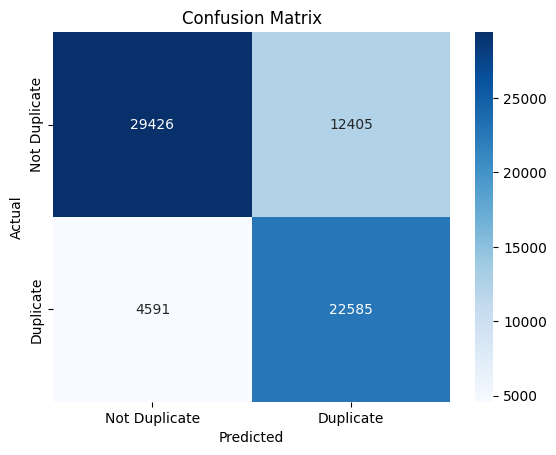

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, best_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Duplicate', 'Duplicate'],
            yticklabels=['Not Duplicate', 'Duplicate'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# **Intermediate Model: BiLSTM with GloVe Embeddings**

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### **Tokenization**

In [17]:
MAX_VOCAB  = 50000   # vocabulary size
MAX_LEN    = 30      # max tokens per question
EMBED_DIM  = 100     # GloVe dimension

# Fit tokenizer on all questions
all_texts = pd.concat([df['question1'], df['question2']]).astype(str).tolist()

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(all_texts)

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")

Vocabulary size: 81974


### **Download GloVe Embeddings**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, urllib.request

GLOVE_PATH = "/content/drive/MyDrive/glove.6B.100d.txt"

if not os.path.exists(GLOVE_PATH):
    print("Downloading GloVe...")
    urllib.request.urlretrieve(
        "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip",
        "/content/glove.6B.zip"
    )
    with zipfile.ZipFile("/content/glove.6B.zip", "r") as z:
        z.extract("glove.6B.100d.txt", "/content/drive/MyDrive/")
    print("Done!")
else:
    print("GloVe already downloaded in Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!


### **Build Embedding Matrix**

In [20]:
# Load GloVe vectors
glove_embeddings = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype='float32')
        glove_embeddings[word] = vec

print(f"GloVe vectors loaded: {len(glove_embeddings)}")

# Build embedding matrix
vocab_size = min(MAX_VOCAB, len(word_index)) + 1
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

for word, idx in word_index.items():
    if idx < vocab_size:
        vec = glove_embeddings.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

print(f"Embedding matrix shape: {embedding_matrix.shape}")

GloVe vectors loaded: 400000
Embedding matrix shape: (50001, 100)


### **Prepare Sequences**

In [21]:
def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts.astype(str).tolist())
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

# Use same train/test split as Model 1 (X_train, X_test)
q1_train_seq = encode(X_train['question1'])
q2_train_seq = encode(X_train['question2'])
q1_test_seq  = encode(X_test['question1'])
q2_test_seq  = encode(X_test['question2'])

y_train_arr = y_train.values
y_test_arr  = y_test.values

print(f"Train shape: {q1_train_seq.shape}")
print(f"Test  shape: {q1_test_seq.shape}")

Train shape: (276026, 30)
Test  shape: (69007, 30)


### **BiLSTM Model Architecture**

In [22]:
def build_bilstm_model(vocab_size, embed_dim, embedding_matrix, max_len):
    # Shared embedding + BiLSTM encoder
    input_q1 = Input(shape=(max_len,), name='q1')
    input_q2 = Input(shape=(max_len,), name='q2')

    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False   # freeze GloVe weights
    )

    bilstm = Bidirectional(LSTM(64, return_sequences=False))

    enc_q1 = bilstm(embedding(input_q1))
    enc_q2 = bilstm(embedding(input_q2))

    # Combine: concatenate + absolute difference
    diff    = Lambda(lambda t: K.abs(t[0] - t[1]))([enc_q1, enc_q2])
    merged  = tf.keras.layers.Concatenate()([enc_q1, enc_q2, diff])

    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[input_q1, input_q2], outputs=output)
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

bilstm_model = build_bilstm_model(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN)
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ q1 (InputLayer)     │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q2 (InputLayer)     │ (None, 30)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 100)   │  5,000,100 │ q1[0][0],         │
│ (Embedding)         │                   │            │ q2[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     84,480 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ bidirectional[0]… │
│                     │                   │            │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[1]… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,133,989 (19.58 MB)

 Trainable params: 133,889 (523.00 KB)

 Non-trainable params: 5,000,100 (19.07 MB)

### **Train BiLSTM**

In [23]:
history = bilstm_model.fit(
    [q1_train_seq, q2_train_seq], y_train_arr,
    validation_split=0.1,
    epochs=5,
    batch_size=256,
    verbose=1
)

Epoch 1/5
971/971 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7387 - loss: 0.5048 - val_accuracy: 0.7819 - val_loss: 0.4487
Epoch 2/5
971/971 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.7897 - loss: 0.4334 - val_accuracy: 0.7972 - val_loss: 0.4246
Epoch 3/5
971/971 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8086 - loss: 0.4041 - val_accuracy: 0.7974 - val_loss: 0.4231
Epoch 4/5
971/971 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8197 - loss: 0.3837 - val_accuracy: 0.8092 - val_loss: 0.4022
Epoch 5/5
971/971 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.8304 - loss: 0.3666 - val_accuracy: 0.8156 - val_loss: 0.3958


### **Prediction and Evaluation**

270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Accuracy : 0.8150
Precision: 0.7616
Recall   : 0.7720
F1 Score : 0.7668


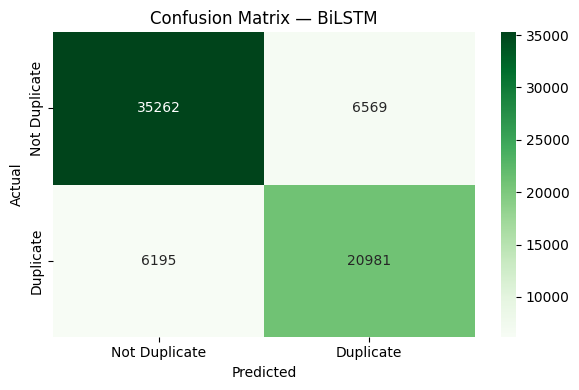

In [39]:
y_prob = bilstm_model.predict([q1_test_seq, q2_test_seq], batch_size=256).flatten()
y_pred_bilstm = (y_prob >= 0.5).astype(int)

bilstm_acc  = accuracy_score(y_test_arr, y_pred_bilstm)
bilstm_prec = precision_score(y_test_arr, y_pred_bilstm)
bilstm_rec  = recall_score(y_test_arr, y_pred_bilstm)
bilstm_f1   = f1_score(y_test_arr, y_pred_bilstm)

print(f"Accuracy : {bilstm_acc:.4f}")
print(f"Precision: {bilstm_prec:.4f}")
print(f"Recall   : {bilstm_rec:.4f}")
print(f"F1 Score : {bilstm_f1:.4f}")

# Confusion Matrix
cm_bilstm = confusion_matrix(y_test_arr, y_pred_bilstm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Duplicate', 'Duplicate'],
            yticklabels=['Not Duplicate', 'Duplicate'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — BiLSTM")
plt.tight_layout()
plt.show()

### **Training Curves**

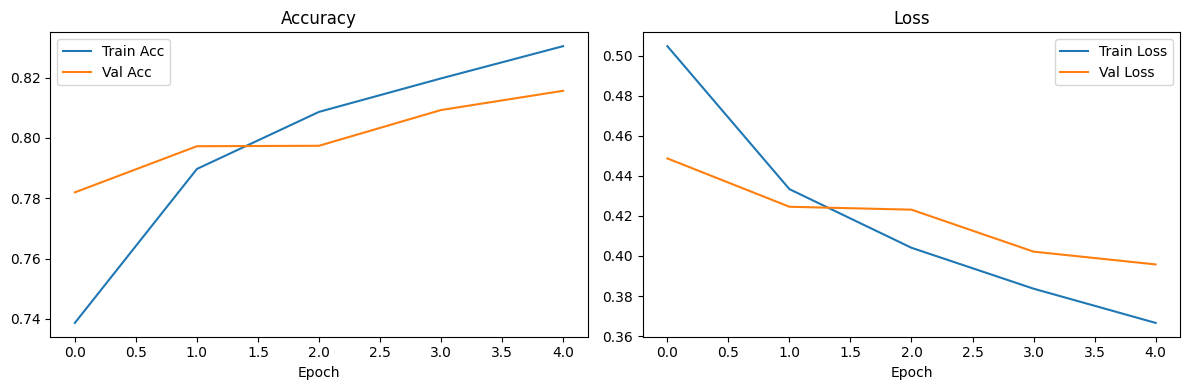

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# **Advanced Model: Sentence-BERT (Siamese Transformer Architecture)**

In [49]:
!pip install -q sentence-transformers datasets

In [50]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import pandas as pd

/tmp/ipykernel_1947/2019900857.py:1: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


### **Prepare training data**

In [52]:
train_examples = []

for q1, q2, label in zip(X_train['question1'], X_train['question2'], y_train):
    train_examples.append(InputExample(texts=[str(q1), str(q2)], label=float(label)))

### **Load base SBERT model**

In [53]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### **DataLoader**

In [54]:
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

### **Loss function**

In [55]:
train_loss = losses.CosineSimilarityLoss(model)

### **Fine-tuning**

In [56]:
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,                 # start with 1–3
    warmup_steps=100,
    show_progress_bar=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.175996
1000,0.150408
1500,0.142555
2000,0.139847
2500,0.136252
3000,0.136154
3500,0.132510
4000,0.127613
4500,0.127032
5000,0.124201


In [57]:
fine_tuned_sbert = model

### **Generate embeddings**

In [58]:
q1_test_emb = fine_tuned_sbert.encode(X_test['question1'].astype(str).tolist(),
                                      normalize_embeddings=True)

q2_test_emb = fine_tuned_sbert.encode(X_test['question2'].astype(str).tolist(),
                                      normalize_embeddings=True)

test_cos = np.sum(q1_test_emb * q2_test_emb, axis=1)

### **Cosine + Logistic Regression**

In [59]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=2000)
clf.fit(test_cos.reshape(-1,1), y_test)

LogisticRegression(max_iter=2000)

### **Prediction and Evaluation**

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# predictions
probs = clf.predict_proba(test_cos.reshape(-1, 1))[:, 1]
sbert_preds = (probs > 0.5).astype(int)

# metrics (SBERT-named variables)
sbert_acc  = accuracy_score(y_test, sbert_preds)
sbert_prec = precision_score(y_test, sbert_preds)
sbert_rec  = recall_score(y_test, sbert_preds)
sbert_f1   = f1_score(y_test, sbert_preds)

print("SBERT Results")
print("Accuracy :", sbert_acc)
print("Precision:", sbert_prec)
print("Recall   :", sbert_rec)
print("F1 Score :", sbert_f1)

SBERT Results
Accuracy : 0.856029098497254
Precision: 0.8015531535313254
Recall   : 0.8431704445098617
F1 Score : 0.8218352671126016


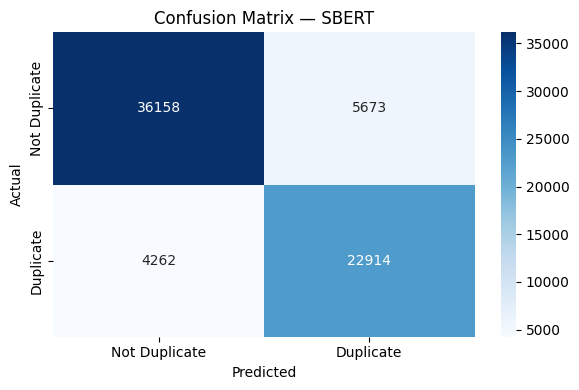

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_sbert = confusion_matrix(y_test, sbert_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm_sbert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Duplicate', 'Duplicate'],
            yticklabels=['Not Duplicate', 'Duplicate'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SBERT")
plt.tight_layout()
plt.show()

# **Model Comparison**

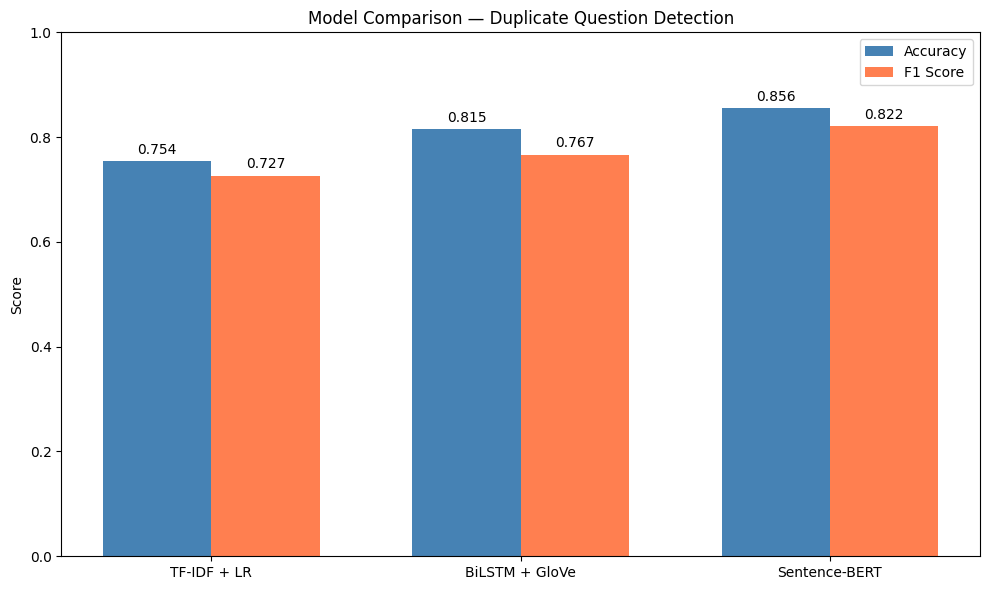

In [65]:
import matplotlib.pyplot as plt
import numpy as np

models = ['TF-IDF + LR', 'BiLSTM + GloVe', 'Sentence-BERT']

accuracy = [tfidf_acc, bilstm_acc, sbert_acc]
f1_scores = [tfidf_f1, bilstm_f1, sbert_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Duplicate Question Detection')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

# value labels
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["TF-IDF", "BiLSTM", "SBERT"],
    "Accuracy": [tfidf_acc, bilstm_acc, sbert_acc],
    "Precision": [tfidf_prec, bilstm_prec, sbert_prec],
    "Recall": [tfidf_rec, bilstm_rec, sbert_rec],
    "F1-Score": [tfidf_f1, bilstm_f1, sbert_f1]
})
comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}"
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF,0.753706,0.645470,0.831064,0.726603
1,BiLSTM,0.815033,0.761561,0.772042,0.766765
2,SBERT,0.856029,0.801553,0.843170,0.821835


# **Gradio UI**

In [66]:
!pip install gradio -q

import gradio as gr
from sklearn.preprocessing import normalize

def predict_duplicate(question1, question2):

    emb1 = sbert.encode([question1], normalize_embeddings=True)
    emb2 = sbert.encode([question2], normalize_embeddings=True)

    # cosine similarity
    cos = np.sum(emb1 * emb2, axis=1)[0]

    # single feature only (stable + best generalization)
    features = np.array([[cos]])

    pred = clf.predict(features)[0]
    prob = clf.predict_proba(features)[0][1]

    label = "✅ Duplicate" if pred == 1 else "❌ Not Duplicate"
    return label, f"{prob:.2%}"

demo = gr.Interface(
    fn=predict_duplicate,
    inputs=[
        gr.Textbox(label="Question 1", placeholder="Enter first question..."),
        gr.Textbox(label="Question 2", placeholder="Enter second question..."),
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence"),
    ],
    title="Duplicate Question Detector",
    description="Enter two questions to check if they are semantically equivalent.",
    examples=[
        ["What is the best way to learn Python?", "How should I start learning Python programming?"],
        ["What is the capital of France?", "How do I cook pasta?"],
        ["How do I lose weight fast?", "What is the quickest way to reduce body fat?"],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d69fb25cc45b6c525d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
